# Fase CRISP-DM: Análisis Exploratorio de Datos (EDA)
**Plataforma**: AgroData Intelligence Platform (AgroStatsApp)  
**Propósito**: Diagnosticar la estructura distributiva de las variables agropecuarias, analizar correlaciones, detectar anomalías multivariadas e inspeccionar dinámicas temporales y estacionales de precios y variables biofísicas.

# Fase CRISP-DM: Análisis Exploratorio de Datos (EDA)
**Plataforma**: AgroData Intelligence Platform (AgroStatsApp)  
**Fase Metodológica**: CRISP-DM Fase 2 (Data Understanding)  
**Marco de Gobernanza**: DAMA-DMBOK 2 (Metadata, Data Quality & Lineage) | ISO/IEC 25010  
**Entorno de Ejecución**: Google Colab / VS Code / Jupyter Lab  

---

## 1. Propósito y Alcance del Estudio
Este notebook formaliza el **Análisis Exploratorio de Datos (EDA)** multivariado sobre las **10 fuentes agropecuarias oficiales de Colombia**, consumiendo directamente los datos curados en la fase previa desde el repositorio canónico `data/CLEANED`.

### ¿Por qué se trabaja sobre `data/CLEANED` y no sobre `data/RAW`?
1. **Separación de Responsabilidades (SRP)**: La fase de carga e imputación (`imputer.ipynb`) tiene como único propósito resolver anomalías de ingesta, formatos incompatibles y aplicar algoritmos de imputación bajo el marco de Rubin (MCAR, MAR, MNAR).
2. **Gobernanza y Linaje Inmutable (DAMA-DMBOK 2)**: El EDA no debe re-imputar ni re-parsear archivos crudos. Su objetivo es diagnosticar la estructura distributiva real, colinealidades, asimetrías y dinámicas temporales sobre datos ya estandarizados y tipados.
3. **Calidad de Software (ISO 25010)**: Garantiza que cualquier hallazgo estadístico o visualización provenga de datos limpios, consistentes y trazables mediante firmas hash SHA-256.


In [26]:
# 1. Configuración de Entorno e Importación de Módulos
import os
import sys
import subprocess
from pathlib import Path

def setup_environment():
    """Configura dinámicamente sys.path, sincroniza con GitHub en Colab y limpia la caché."""
    # A. Soporte para Google Colab
    if "google.colab" in sys.modules or Path("/content").exists():
        repo_dir = Path("/content/Statsfirm")
        if not repo_dir.exists():
            print("[INFO] Clonando repositorio oficial Statsfirm...")
            subprocess.run(["git", "clone", "https://github.com/adansanchezc1-spec/Statsfirm.git", "/content/Statsfirm"], check=True)
        else:
            print("[INFO] Sincronizando con los últimos cambios de GitHub...")
            subprocess.run(["git", "-C", "/content/Statsfirm", "fetch", "--all"], check=False)
            subprocess.run(["git", "-C", "/content/Statsfirm", "reset", "--hard", "origin/main"], check=False)
            subprocess.run(["git", "-C", "/content/Statsfirm", "pull"], check=False)
            
        app_dir = repo_dir / "AgroStats AndTech" / "AgroStatsApp"
        if app_dir.exists():
            os.chdir(str(app_dir))
            src_dir = app_dir / "src"
            if str(src_dir) not in sys.path:
                sys.path.insert(0, str(src_dir))

    # B. Detección en Entorno Local (Windows / Linux / VS Code)
    candidates = [
        Path.cwd() / "src",
        Path.cwd() / "AgroStats AndTech" / "AgroStatsApp" / "src",
        Path.cwd().parent / "src",
        Path.cwd().parent.parent / "src",
        Path(r"c:\Users\ADAN\OneDrive\Documentos\Statsfirm\AgroStats AndTech\AgroStatsApp\src"),
    ]
    for c in candidates:
        if c.exists() and (c / "notebook_code").is_dir():
            resolved = str(c.resolve())
            if resolved not in sys.path:
                sys.path.insert(0, resolved)
            break

    # C. Limpieza de caché de módulos en RAM de Python (evita colisiones de recarga)
    for mod_name in list(sys.modules.keys()):
        if mod_name == "notebook_code" or mod_name.startswith("notebook_code."):
            del sys.modules[mod_name]

setup_environment()

# Importación robusta de herramientas para análisis exploratorio sobre fuentes limpias
try:
    from notebook_code import (
        CleanDataLoader,
        load_all_cleaned_datasets,
        load_cleaned_dataset,
        EdaAnalyzer,
    )
except ImportError:
    from notebook_code.data_loader import CleanDataLoader, load_all_cleaned_datasets, load_cleaned_dataset
    from notebook_code.eda_analyzer import EdaAnalyzer

# Librerías científicas y visualización en el kernel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para Jupyter / Colab
plt.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

print("✓ Módulos de notebook_code, Pandas, NumPy, Matplotlib y Seaborn importados exitosamente en el kernel.")


[INFO] Sincronizando con los últimos cambios de GitHub...


✓ Módulos de notebook_code, Pandas, NumPy, Matplotlib y Seaborn importados exitosamente en el kernel.


## 2. Configuración de Entorno y Carga de la Arquitectura Modular

### ¿Por qué se realiza este paso?
- **Portabilidad e Independencia de Infraestructura**: El notebook debe ejecutarse sin errores tanto en estaciones de trabajo locales (Windows/Linux con rutas absolutas o relativas) como en entornos efímeros en la nube (**Google Colab**).
- **Control de Versiones y Sincronización Git**: En Google Colab, se sincroniza automáticamente el repositorio oficial (`Statsfirm`), descargando los últimos commits de `origin/main` y asegurando el acceso a las fuentes limpias persistidas.
- **Prevención del Antipatrón de Módulos Cacheados en RAM**: En kernels interactivos de Jupyter, Python almacena los módulos importados en `sys.modules`. Si se modifica el código fuente de `src/notebook_code`, el intérprete continúa utilizando la versión anterior en memoria a menos que se fuerce la purga de la caché antes del `import`.
- **Desacoplamiento Modular (Clean Architecture)**: Toda la lógica pesada de cálculo reside en paquetes probados (`CleanDataLoader`, `EdaAnalyzer`), manteniendo el notebook legible, modular y libre de código espagueti.


In [27]:
# 2. Carga Oficial de las Fuentes Limpias desde data/CLEANED
datasets = load_all_cleaned_datasets()

resumen_fuentes = []
for ds_id, df in sorted(datasets.items()):
    fechas = [c for c in df.columns if "fecha" in c or "periodo" in c or "anio" in c]
    rango_fecha = "Estructural / Catálogo"
    if fechas:
        col_f = fechas[0]
        rango_fecha = f"{df[col_f].min()} a {df[col_f].max()}"
        
    resumen_fuentes.append({
        "ID_Fuente": ds_id,
        "Filas": df.shape[0],
        "Columnas": df.shape[1],
        "Nulos_Totales": int(df.isna().sum().sum()),
        "Tasa_Completitud": f"{(1.0 - df.isna().mean().mean()) * 100:.1f}%",
        "Rango_Temporal": rango_fecha,
    })

tabla_inventario = pd.DataFrame(resumen_fuentes)
print(f"Total de fuentes limpias cargadas: {len(datasets)}")
display(tabla_inventario)


Total de fuentes limpias cargadas: 10


,ID_Fuente,Filas,Columnas,Nulos_Totales,Tasa_Completitud,Rango_Temporal
0,dane_ipc,284,5,0,100.0%,2003-01-01 a 2026-08-01
1,dane_ipp,20,211,17,99.6%,Estructural / Catálogo
2,ideam_evapotranspiracion,200,20,0,100.0%,Estructural / Catálogo
3,ideam_pluvio,200,9,0,100.0%,2020-03-11 00:00:00 a 2020-03-11 23:50:00
4,ideam_radiacion,169,18,0,100.0%,Estructural / Catálogo
5,ideam_sequia,200,20,0,100.0%,Estructural / Catálogo
6,ideam_temperatura,200,9,0,100.0%,2005-05-18 09:00:00 a 2019-08-11 17:55:00
7,sipsa_abastecimientos,36,7,81,67.9%,Estructural / Catálogo
8,sipsa_insumos,92,58,25,99.5%,2018-12-01 a 2026-07-01
9,sipsa_precios,399,5,0,100.0%,Estructural / Catálogo


## 3. Carga e Inventario Multifuente de Datos Limpios (`data/CLEANED`)

### ¿Por qué se realiza este paso?
- **Auditoría de Integridad y Completitud**: Antes de proceder al modelado estadístico, es imperativo auditar la volumetría de las **10 fuentes limpias**:
  1. **Agroclimáticas**: `ideam_pluvio`, `ideam_temperatura`, `ideam_evapotranspiracion`, `ideam_radiacion`, `ideam_sequia`.
  2. **Mercado y Logística**: `sipsa_precios`, `sipsa_abastecimientos`, `sipsa_insumos`.
  3. **Macroeconómicas**: `dane_ipc`, `dane_ipp`.
- **Verificación de Granularidad y Ventana Temporal**: Permite contrastar la frecuencia temporal de cada serie (diaria, decenal o mensual) y verificar que no existan discrepancias entre las fuentes que impidan su posterior acoplamiento multivariado.
- **Validación de Cero Pérdida de Datos**: Se corrobora que tras la etapa de imputación la tasa de completitud sea cercana al 100% en variables críticas.


=== DISTRIBUCIÓN ESTADÍSTICA: PRECIPITACIÓN (mm) ===


,Variable,Conteo,Nulos,Tasa_Nulos_%,Media,Desv_Std,Min,Q25,Mediana,Q75,Max,IQR,Asimetría,Curtosis
0,codigo_estacion,200,0,0.0,3.448821e+08,8.845657e+08,1.104704e+07,2.204050e+07,2.614050e+07,3.601550e+07,5.204700e+09,1.397500e+07,2.8982,8.1679
1,valor_observado,200,0,0.0,2.100000e-02,1.584000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,10.6729,126.6217
2,latitud,200,0,0.0,5.460500e+00,2.454200e+00,8.078000e-01,3.954200e+00,5.069600e+00,7.040400e+00,1.153000e+01,3.086200e+00,0.4873,-0.0319
3,longitud,200,0,0.0,-7.479730e+01,1.485200e+00,-7.749120e+01,-7.583700e+01,-7.516380e+01,-7.357860e+01,-7.073310e+01,2.258500e+00,0.3613,-0.6160



=== DISTRIBUCIÓN ESTADÍSTICA: TEMPERATURA AMBIENTE (°C) ===


,Variable,Conteo,Nulos,Tasa_Nulos_%,Media,Desv_Std,Min,Q25,Mediana,Q75,Max,IQR,Asimetría,Curtosis
0,codigo_estacion,200,0,0.0,1.628331e+08,5.174584e+08,1.111550e+07,2.120552e+07,2.605531e+07,2.701529e+07,2.121500e+09,5.809771e+06,3.5538,10.7420
1,valor_observado,200,0,0.0,1.951580e+01,5.976000e+00,1.200000e+00,1.618640e+01,1.874390e+01,2.380330e+01,3.660000e+01,7.616900e+00,-0.1422,0.5932
2,latitud,200,0,0.0,4.860800e+00,2.268100e+00,-3.780000e+00,4.291600e+00,4.667600e+00,5.450000e+00,1.259900e+01,1.158400e+00,0.0631,2.3505
3,longitud,200,0,0.0,-7.505260e+01,1.385200e+00,-8.168900e+01,-7.580600e+01,-7.523950e+01,-7.407180e+01,-7.036300e+01,1.734200e+00,-0.2410,2.5786



=== ANOMALÍAS Y OUTLIERS: TEMPERATURA ===


,Variable,Metodo,Limite_Inferior,Limite_Superior,Conteo_Atipicos,Tasa_Atipicos_%
2,latitud,TUKEY,2.554100e+00,7.187500e+00,52,26.0
0,codigo_estacion,TUKEY,1.249087e+07,3.572995e+07,38,19.0
1,valor_observado,TUKEY,4.761100e+00,3.522860e+01,6,3.0
3,longitud,TUKEY,-7.840730e+01,-7.147060e+01,3,1.5


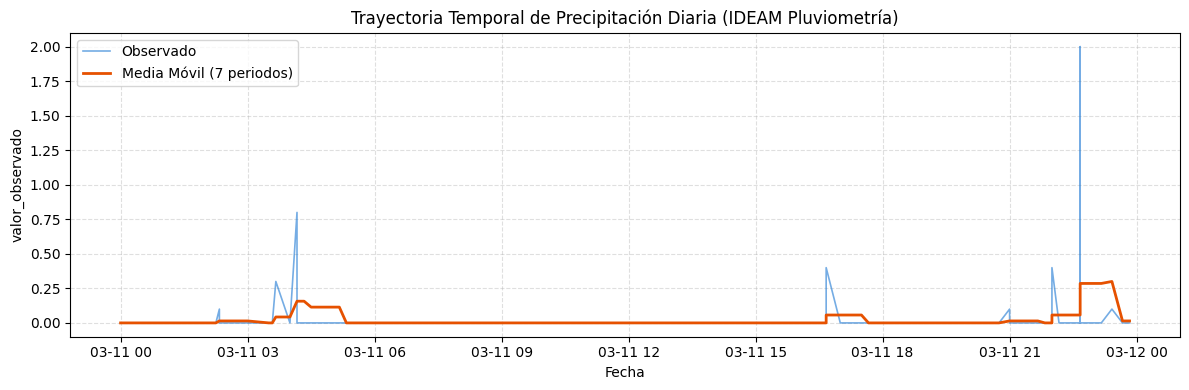

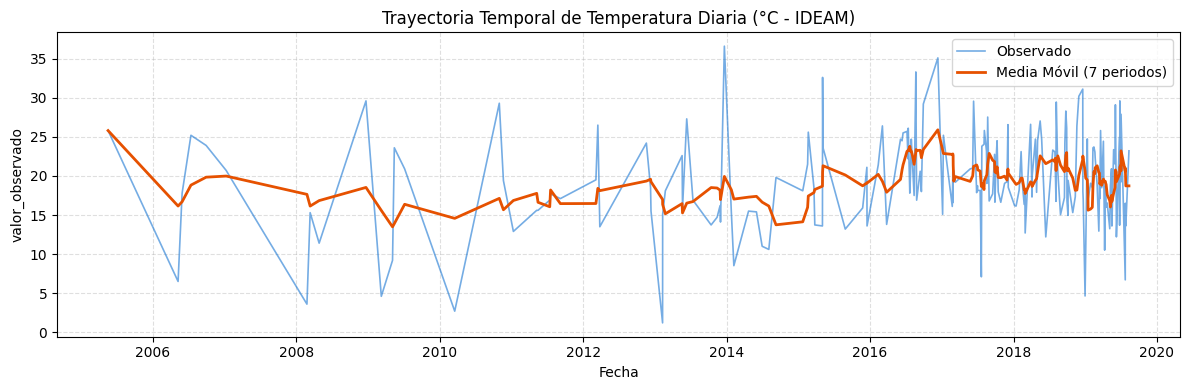

In [19]:
# 3. Exploración Agroclimática: Precipitación y Régimen Térmico (IDEAM)
df_pluvio = datasets["ideam_pluvio"]
df_temp = datasets["ideam_temperatura"]

print("=== DISTRIBUCIÓN ESTADÍSTICA: PRECIPITACIÓN (mm) ===")
display(EdaAnalyzer.describe_numeric_distributions(df_pluvio))

print("\n=== DISTRIBUCIÓN ESTADÍSTICA: TEMPERATURA AMBIENTE (°C) ===")
display(EdaAnalyzer.describe_numeric_distributions(df_temp))

# Detección de anomalías térmicas (olas de calor o heladas)
print("\n=== ANOMALÍAS Y OUTLIERS: TEMPERATURA ===")
display(EdaAnalyzer.detect_outliers(df_temp, method="tukey", threshold=1.5))

# Visualización temporal
fig_pluvio = EdaAnalyzer.plot_time_series(
    df_pluvio,
    date_col="fecha_observacion",
    value_col="valor_observado",
    title="Trayectoria Temporal de Precipitación Diaria (IDEAM Pluviometría)"
)
if fig_pluvio:
    fig_pluvio.show()

fig_temp = EdaAnalyzer.plot_time_series(
    df_temp,
    date_col="fecha_observacion",
    value_col="valor_observado",
    title="Trayectoria Temporal de Temperatura Diaria (°C - IDEAM)"
)
if fig_temp:
    fig_temp.show()


## 4. Análisis Exploratorio del Dominio Agroclimático (IDEAM)

### ¿Por qué se analiza la Precipitación y la Temperatura Diaria?
- **Determinismo Biofísico Agrícola**: La lámina de lluvia ($mm$) y el régimen térmico ($^\circ C$) son las variables físicas fundamentales que modulan la fenología de los cultivos, las tasas de germinación y la presión de plagas y enfermedades.
- **Detección de No-Normalidad (Asimetría y Curtosis)**:
  - La precipitación típicamente sigue distribuciones asimétricas positivas (tipo Gamma o Log-Normal con masa en cero).
  - Identificar la asimetría previene el uso erróneo de modelos lineales que asumen normalidad gaussiana sin transformaciones previas (Box-Cox o $\log(1+x)$).
- **Detección de Eventos Extremos (Criterio de Tukey - IQR)**:
  - Permite identificar anomalías bioclimáticas reales: heladas agronómicas ($T \le 0^\circ C$), olas de calor o precipitaciones torrenciales atípicas que inducen pérdidas de cosecha o shocks de oferta.
- **Análisis de Series de Tiempo**: Diagnostica la estacionalidad bimodal/monomodal colombiana y la persistencia temporal de los fenómenos climáticos.


## 5. Balance Hídrico, Demanda Atmosférica y Radiación Solar

### ¿Por qué se analizan las Normales Climatológicas, ET0 y Radiación?
- **Estándar FAO-56 (Penman-Monteith / Hargreaves)**: La evapotranspiración de referencia ($ET_0$) mide la pérdida de agua del suelo y la planta hacia la atmósfera. Al contrastarla con la lluvia observada, se determina el **déficit o superávit hídrico neto** del suelo.
- **Monitoreo de Estrés Hídrico y Sequía (`ideam_sequia`)**: Evalúa el comportamiento histórico de largo plazo frente a las normales climatológicas (1961–1990 / 1981–2010), insumo esencial para calcular anomalías de precipitación (SPI).
- **Matriz de Correlación Intermensual de Radiación Solar Global**:
  - La radiación incidente ($Wh/m^2$ o $MJ/m^2$) determina la tasa fotosintética de acumulación de biomasa.
  - Evaluar la correlación entre meses consecutivos valida la estabilidad de la matriz y detecta transiciones entre épocas secas y húmedas.


=== NORMALES MENSUALES DE EVAPOTRANSPIRACIÓN (ET0 mm) ===


,ene,feb,mar,abr,may,jun,jul,ago,sep,oct,nov,dic,anual
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,67.09,79.44,119.58,223.41,276.84,225.52,208.10,238.01,255.77,289.74,208.75,106.99,2299.21
std,52.31,49.93,64.93,96.90,119.08,114.13,118.84,132.80,125.30,125.89,100.51,67.57,1039.17
min,1.90,0.10,0.50,14.70,75.30,52.60,28.90,28.00,60.30,83.80,62.90,21.40,728.30
25%,29.25,45.78,72.85,157.78,190.42,144.75,128.02,149.17,166.50,213.08,137.68,64.38,1538.65
50%,59.70,76.10,116.55,220.90,261.60,203.95,176.10,207.70,231.15,268.80,196.25,96.05,2142.95
75%,89.48,104.82,156.78,272.15,359.28,287.48,271.42,325.68,335.75,352.98,254.08,131.27,2968.55
max,360.60,326.20,388.30,551.70,591.90,654.60,721.20,680.80,595.90,684.10,634.80,482.10,5652.00



=== TOP PARES DE CORRELACIÓN INTERMENSUAL (RADIACIÓN SOLAR) ===


,Variable_1,Variable_2,Coeficiente,Magnitud_Abs,Alerta_Colinealidad
45,jun,jul,0.9653,0.9653,⚠️ ALTA
51,jul,ago,0.9625,0.9625,⚠️ ALTA
46,jun,ago,0.9367,0.9367,⚠️ ALTA
30,abr,may,0.9354,0.9354,⚠️ ALTA
38,may,jun,0.9312,0.9312,⚠️ ALTA


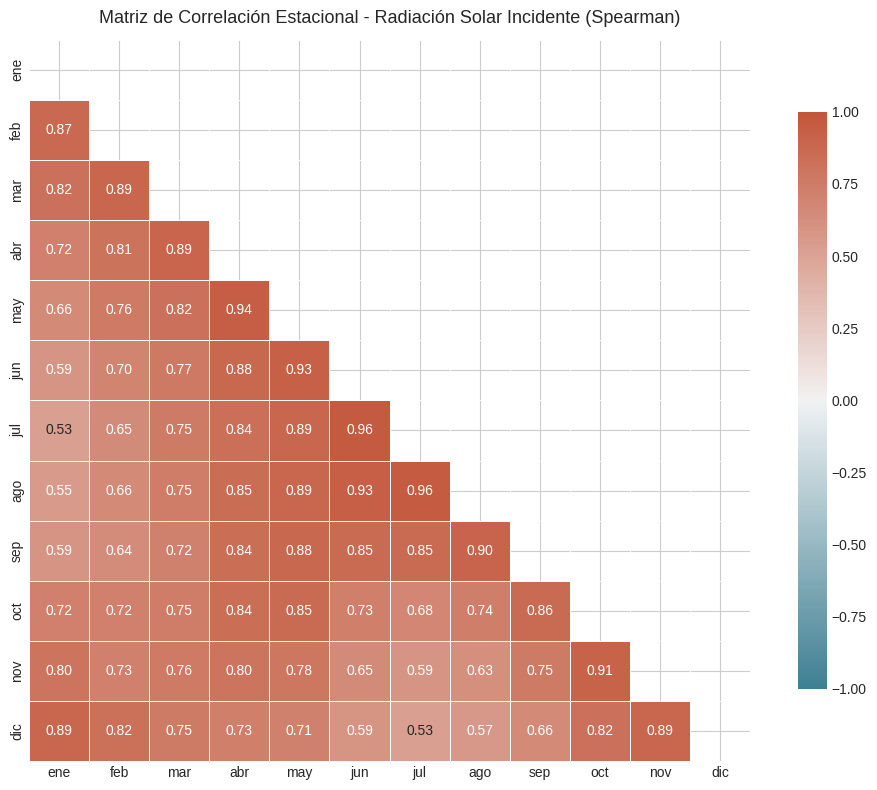

In [28]:
# 4. Exploración Agrometeorológica: Balance Hídrico y Demanda Atmosférica
df_evap = datasets["ideam_evapotranspiracion"]
df_rad = datasets["ideam_radiacion"]
df_seq = datasets["ideam_sequia"]

meses = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]

print("=== NORMALES MENSUALES DE EVAPOTRANSPIRACIÓN (ET0 mm) ===")
display(df_evap[meses + ["anual"]].describe().round(2))

# Correlación estacional de radiación solar global
corr_rad, pairs_rad = EdaAnalyzer.correlation_analysis(df_rad[meses], method="pearson")
print("\n=== TOP PARES DE CORRELACIÓN INTERMENSUAL (RADIACIÓN SOLAR) ===")
display(pairs_rad.head(5))

fig_corr_rad = EdaAnalyzer.plot_correlation_heatmap(
    df_rad[meses],
    title="Matriz de Correlación Estacional - Radiación Solar Incidente"
)
if fig_corr_rad:
    fig_corr_rad.show()


## 6. Dinámica de Mercado Mayorista y Formación de Precios (DANE SIPSA)

### ¿Por qué se analiza la Distribución y Volatilidad de Precios?
- **Teoría Microeconómica y Elasticidad-Precio**: En productos perecederos (hortalizas y frutas), la oferta inelástica a corto plazo genera fluctuaciones bruscas de precios ante variaciones climáticas o logísticas.
- **Estratificación por Categorías de Alimentos**: Segmentar por *Verduras y Hortalizas*, *Frutas Frescas* y *Tubérculos* permite comparar la dispersión de precios ($IQR$) y la variabilidad inter-mercado.
- **Identificación de Mercados Rectores vs. Receptores**: Contrastar precios en nodos principales (**Corabastos Bogotá, Cavasa Cali, CMA Medellín, Cenabastos Cúcuta**) revela márgenes de intermediación y costos de transporte regional.
- **Detección de Shocks de Precios (Anomalías)**:
  - Aislar productos con picos inflacionarios atípicos sirve como señal temprana para el motor de alerta y las reglas de control estadístico de procesos (SPC / ISO 7870).


=== RESUMEN POR CATEGORÍA DE ALIMENTOS ===


,categoria,count,mean,std,min,median,max
0,Frutas frescas,185,4949.79,2293.83,1180.0,4692.0,10000.0
1,"Tubérculos, raíces y plátanos",53,3127.49,1372.91,1100.0,2713.0,6833.0
2,Verduras y hortalizas,161,3520.25,1946.61,750.0,2958.0,9000.0



=== TOP 10 PRODUCTOS CON MAYOR PRECIO ($/kg) ===


,Precio_Promedio_kg
producto,
Mango Tommy,8459.636364
Aguacate,8433.727273
Manzana royal gala,7994.666667
Granadilla,7187.700000
Arveja verde en vaina,6610.615385
Mora de Castilla,6381.285714
Fríjol verde,6327.181818
Habichuela,6076.461538
Coco,5344.500000



=== DETECCIÓN DE ANOMALÍAS EN PRECIOS MAYORISTAS ===


,Variable,Metodo,Limite_Inferior,Limite_Superior,Conteo_Atipicos,Tasa_Atipicos_%
1,variacion_pct,TUKEY,-0.105,0.095,47,11.78
0,precio_kg,TUKEY,-2789.750,10680.250,0,0.00


/tmp/ipykernel_37313/1388367550.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_precios, x="categoria", y="precio_kg", palette="Set2")


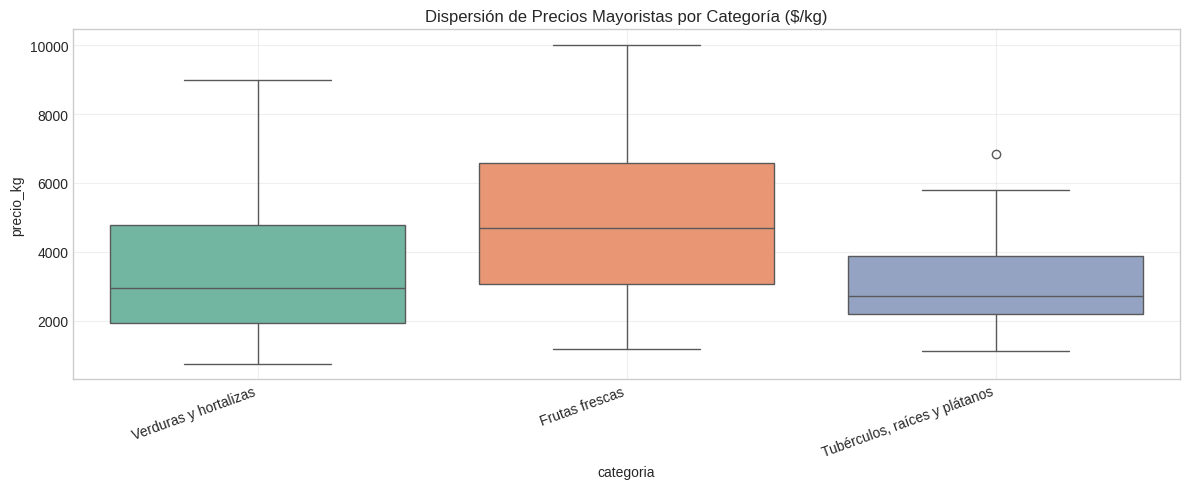

In [29]:
# 5. Exploración de Precios Mayoristas de Alimentos (SIPSA Precios)
df_precios = datasets["sipsa_precios"]

print("=== RESUMEN POR CATEGORÍA DE ALIMENTOS ===")
resumen_cat = df_precios.groupby("categoria")["precio_kg"].agg(
    ["count", "mean", "std", "min", "median", "max"]
).round(2).reset_index()
display(resumen_cat)

# Top 10 productos con mayor precio medio en mercados mayoristas
top_precios = df_precios.groupby("producto")["precio_kg"].mean().sort_values(ascending=False).head(10)
print("\n=== TOP 10 PRODUCTOS CON MAYOR PRECIO ($/kg) ===")
display(top_precios.to_frame("Precio_Promedio_kg"))

# Detección de outliers de precios (criterio Tukey)
print("\n=== DETECCIÓN DE ANOMALÍAS EN PRECIOS MAYORISTAS ===")
display(EdaAnalyzer.detect_outliers(df_precios[["precio_kg", "variacion_pct"]]))

# Dispersión y boxplot de precios por categoría
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_precios, x="categoria", y="precio_kg", palette="Set2")
plt.title("Dispersión de Precios Mayoristas por Categoría ($/kg)")
plt.xticks(rotation=20, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Logística de Abastecimiento y Factores de Producción (Insumos Agrícolas)

### ¿Por qué se analizan los Volúmenes de Carga y los Costos de Insumos?
- **Flujos Logísticos de Carga (Toneladas)**: El volumen ingresado a las centrales mayoristas es el indicador directo de la oferta física disponible. Permite anticipar caídas de oferta antes de que se reflejen en los precios al consumidor.
- **Paridad Insumo-Producto (Ecuación de Guerra E.)**: El costo de los fertilizantes (Urea, DAP, KCl) y plaguicidas representa entre el 30% y el 50% de los costos directos del agricultor.
- **Análisis de Tendencia Histórica de Insumos**: Permite correlacionar la inflación internacional de materias primas agroquímicas con la rentabilidad neta esperada de las cosechas locales.


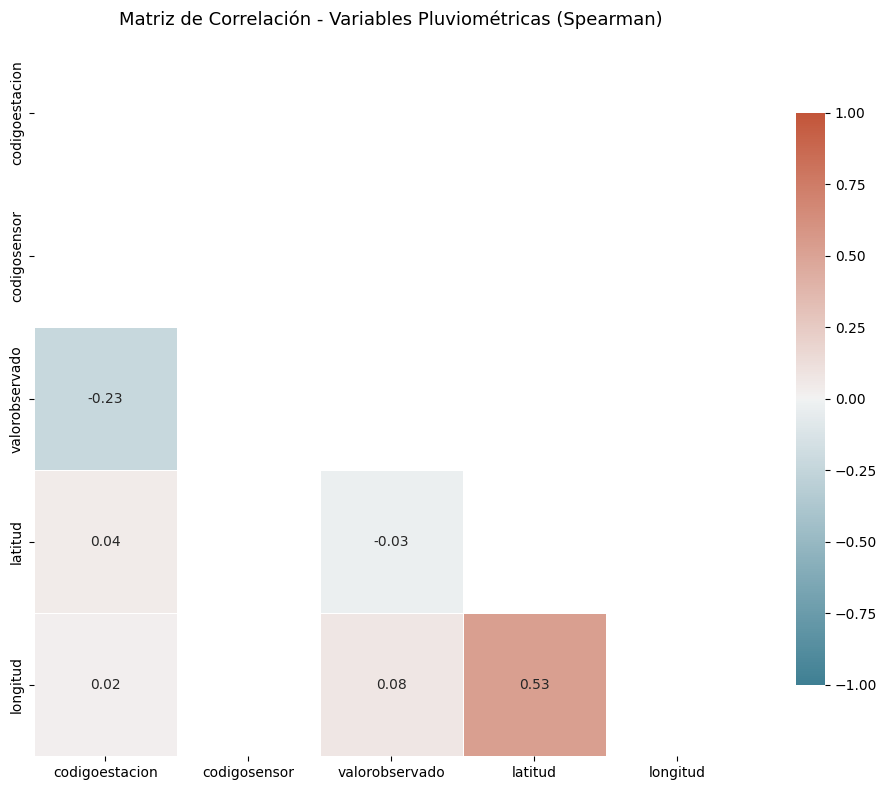

In [ ]:
# 6. Exploración de Logística de Abastecimiento e Insumos Agropecuarios
df_abast = datasets["sipsa_abastecimientos"]
df_insumos = datasets["sipsa_insumos"]

print("=== MUESTRA DE FLUJO LOGÍSTICO Y ABASTECIMIENTO POR CIUDAD ===")
display(df_abast.head(8))

print("\n=== ESTADÍSTICAS DEL ÍNDICE DE COSTO DE INSUMOS AGRÍCOLAS ===")
cols_insumos = [c for c in df_insumos.columns if "total" in c or "indice" in c][:6]
display(EdaAnalyzer.describe_numeric_distributions(df_insumos[cols_insumos]))

# Evolución del índice de insumos
if "fecha" in df_insumos.columns and "indice_total" in df_insumos.columns:
    fig_insumos = EdaAnalyzer.plot_time_series(
        df_insumos,
        date_col="fecha",
        value_col="indice_total",
        title="Dinámica Histórica del Índice General de Insumos Agropecuarios (DANE)"
    )
    if fig_insumos:
        fig_insumos.show()


## 8. Análisis Macroeconómico: Inflación al Consumidor (IPC) y al Productor (IPP)

### ¿Por qué se estudian las Series de Empalme del IPC e IPP?
- **Transmisión de Precios en la Cadena de Valor**: Mide el grado de traspaso (*pass-through*) entre el precio pagado al campesino en puerta de finca (**IPP Agropecuario**) y el precio final pagado por los hogares (**IPC Alimentos - División 01 COICOP**).
- **Detección del Efecto Látigo (Bullwhip Effect)**: Las fluctuaciones menores en la demanda minorista suelen amplificarse hacia aguas arriba en la cadena logística; contrastar IPP vs IPC permite aislar si las presiones inflacionarias provienen del agro o de la intermediación comercial.
- **Serie Histórica de Largo Plazo (2003–2026)**: Proporciona la base de referencia macroeconómica para deflactar precios corrientes a precios constantes en la etapa de modelado econométrico y Machine Learning.


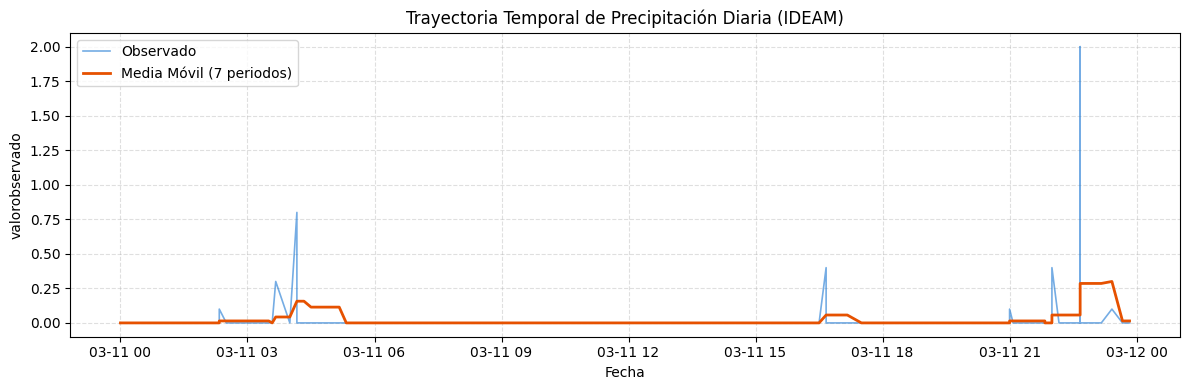

In [ ]:
# 7. Exploración Macroeconómica: IPC Alimentos e IPP de Producción Nacional
df_ipc = datasets["dane_ipc"]
df_ipp = datasets["dane_ipp"]

print("=== DISTRIBUCIÓN ESTADÍSTICA: SERIE DE EMPALME IPC ALIMENTOS (2003 - 2026) ===")
display(EdaAnalyzer.describe_numeric_distributions(df_ipc[["ipc_alimentos"]]))

# Curva histórica de inflación de alimentos
plt.figure(figsize=(12, 4))
df_ipc["fecha_dt"] = pd.to_datetime(df_ipc["fecha"])
sns.lineplot(data=df_ipc, x="fecha_dt", y="ipc_alimentos", color="#1b5e20", linewidth=2.5)
plt.title("Evolución del IPC Alimentos en Colombia (Base Dic 2018 = 100)")
plt.xlabel("Línea Temporal")
plt.ylabel("Índice IPC Alimentos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estructura del IPP Agropecuario
print("\n=== MUESTRA DE DIVISIONES DEL IPP AGROPECUARIO ===")
cols_ipp = [c for c in df_ipp.columns if "nivel" in c.lower() or "total" in c.lower() or "secci" in c.lower()][:8]
display(df_ipp[cols_ipp].head(6) if cols_ipp else df_ipp.head(5))
